In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import os
#导入各种库，有大用
# -------------------- 超参数 --------------------
max_steps = 1000          # 最大迭代次数
learning_rate = 0.001     # 学习率
dropout_keep_prob = 0.9   # dropout时随机保留神经元的比例
data_dir = './MNIST_DATA' # 样本数据存储路径
log_dir = './MNIST_LOG'   # 日志保存路径

batch_size = 100          # 每次迭代的batch大小（与原代码一致）

# -------------------- 设备 --------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")#用于检验我的gpu能不能用

# -------------------- 数据加载 --------------------
transform = transforms.Compose([#把数据预处理步骤组合成流水线，数据经过会依次变换
    transforms.ToTensor(),               # 转换为 [0,1] 的Tensor，形状 (1,28,28)
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST均值和标准差（可选，但可提升收敛）
])

train_dataset = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

# 使用 DataLoader，shuffle 训练集，每次取 batch_size 个样本
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# -------------------- 模型定义 --------------------
class MNISTNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=500, output_dim=10, dropout_keep_prob=0.9):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=1 - dropout_keep_prob)  # dropout 概率
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)          # 展平为 (batch, 784)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)                    # 原始代码输出没有softmax，因为交叉熵损失内部包含softmax
        return x

model = MNISTNet(dropout_keep_prob=dropout_keep_prob).to(device)

# -------------------- 损失函数与优化器 --------------------
criterion = nn.CrossEntropyLoss()          # 包含 softmax + 交叉熵
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# -------------------- TensorBoard SummaryWriter --------------------
writer = SummaryWriter(log_dir=log_dir)

# 记录模型结构到 TensorBoard
dummy_input = torch.randn(1, 1, 28, 28).to(device)
writer.add_graph(model, dummy_input)

# -------------------- 辅助函数：记录参数分布 --------------------
def log_parameters(writer, model, step):
    """记录模型每一层参数的直方图和统计量"""
    for name, param in model.named_parameters():
        if param.requires_grad:
            writer.add_histogram(f'params/{name}', param.data, step)
            writer.add_scalar(f'params_mean/{name}', param.data.mean(), step)
            writer.add_scalar(f'params_std/{name}', param.data.std(), step)
            writer.add_scalar(f'params_max/{name}', param.data.max(), step)
            writer.add_scalar(f'params_min/{name}', param.data.min(), step)

def log_activations(writer, activations, name, step):
    """记录激活值的直方图（需要在 forward 中捕获）"""
    writer.add_histogram(f'activations/{name}', activations, step)

# -------------------- 训练循环 --------------------
step = 0
train_iter = iter(train_loader)   # 用于按步取 batch

for step in range(max_steps):
    # 获取一个 batch 数据（若训练集迭代完则重新开始）
    try:
        images, labels = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        images, labels = next(train_iter)

    images, labels = images.to(device), labels.to(device)

    # 正向传播
    outputs = model(images)
    loss = criterion(outputs, labels)

    # 反向传播与优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # -------------------- 记录训练信息 --------------------
    # 记录损失标量
    writer.add_scalar('loss/train', loss.item(), step)

    # 记录当前步的准确率（训练集）
    _, predicted = torch.max(outputs, 1)
    train_acc = (predicted == labels).float().mean().item()
    writer.add_scalar('accuracy/train', train_acc, step)

    # 每10步记录一次测试集信息（与原代码一致）
    if step % 10 == 0:
        model.eval()                     # 测试模式（关闭dropout）
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for test_images, test_labels in test_loader:
                test_images, test_labels = test_images.to(device), test_labels.to(device)
                test_outputs = model(test_images)
                test_loss += criterion(test_outputs, test_labels).item() * test_images.size(0)
                _, test_pred = torch.max(test_outputs, 1)
                test_correct += (test_pred == test_labels).sum().item()
                test_total += test_labels.size(0)

        test_loss /= test_total
        test_acc = test_correct / test_total

        writer.add_scalar('loss/test', test_loss, step)
        writer.add_scalar('accuracy/test', test_acc, step)

        # 记录模型参数分布（可选，与原代码中 variable_summaries 对应）
        log_parameters(writer, model, step)

        # 记录输入图像（取前10张）
        grid_images = images[:10].cpu()   # 取前10张图像
        writer.add_images('input_images', grid_images, step, dataformats='NCHW')

        print(f"Step {step:4d} | Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        model.train()                     # 恢复训练模式

    else:
        # 仅记录训练信息（与原代码 else 分支一致）
        # 可选择记录参数分布，但为了效率可以不记录，原代码只在测试时记录参数分布
        pass

# -------------------- 关闭 TensorBoard writer --------------------
writer.close()
print("Training finished.")

Using device: cuda:0
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST_DATA\MNIST\raw\train-images-idx3-ubyte.gz to ./MNIST_DATA\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST_DATA\MNIST\raw\train-labels-idx1-ubyte.gz to ./MNIST_DATA\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST_DATA\MNIST\raw\t10k-images-idx3-ubyte.gz to ./MNIST_DATA\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./MNIST_DATA\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./MNIST_DATA\MNIST\raw

Step    0 | Train Loss: 2.3536 | Train Acc: 0.0600 | Test Loss: 2.0919 | Test Acc: 0.3447
Step   10 | Train Loss: 0.6314 | Train Acc: 0.8300 | Test Loss: 0.6472 | Test Acc: 0.8204
Step   20 | Train Loss: 0.3394 | Train Acc: 0.8800 | Test Loss: 0.4580 | Test Acc: 0.8639
Step   30 | Train Loss: 0.5297 | Train Acc: 0.8700 | Test Loss: 0.4216 | Test Acc: 0.8737
Step   40 | Train Loss: 0.3137 | Train Acc: 0.8900 | Test Loss: 0.3715 | Test Acc: 0.8911
Step   50 | Train Loss: 0.3742 | Train Acc: 0.8300 | Test Loss: 0.3400 | Test Acc: 0.9015
Step   60 | Train Loss: 0.2387 | Train Acc: 0.9100 | Test Loss: 0.3100 | Test Acc: 0.9090
Step   70 | Train Loss: 0.3853 | Train Acc: 0.8700 | Test Loss: 0.3008 | Test Acc: 0.9119
Step   80 | Train Loss: 0.5021 | Train Acc: 0.8600 | Test Loss: 0.2798 | Test Acc: 0.9168
Step   90 | Train Loss: 0.2606 | Train Acc: 0.9000 | Test Loss: 0.2786 | Test Acc: 0.9204
Step  100 | T

In [2]:
torch.save(model.state_dict(), 'mnist_model.pth')

# 加载（推荐写法）
model.load_state_dict(torch.load('mnist_model.pth', weights_only=True))

<All keys matched successfully>

In [3]:
# 加载模型结构
model = MNISTNet(dropout_keep_prob=dropout_keep_prob).to(device)
model.load_state_dict(torch.load('mnist_model.pth'))
model.eval()

# 对测试集进行预测
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Final test accuracy: {100 * correct / total:.2f}%')

C:\Users\tenorclef\AppData\Local\Temp\ipykernel_30100\246417937.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('mnist_model.pth'))


Final test accuracy: 96.95%


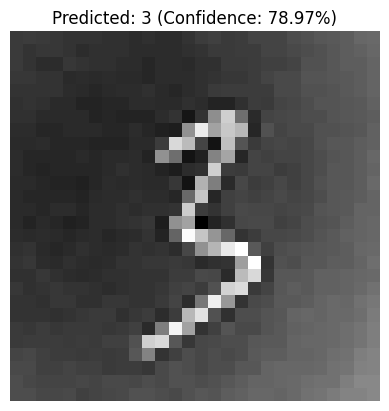

模型预测结果为：3，置信度：78.97%


In [7]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
# ---------- 1. 定义模型结构（必须与训练时完全一致）----------
class MNISTNet(torch.nn.Module):
    def __init__(self, input_dim=784, hidden_dim=500, output_dim=10, dropout_keep_prob=0.9):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=1 - dropout_keep_prob)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 设备（使用训练时的设备）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 实例化模型并加载训练好的参数
model = MNISTNet().to(device)
model.load_state_dict(torch.load('mnist_model.pth', map_location=device, weights_only=True))
model.eval()  # 切换到评估模式，关闭 dropout

# ---------- 2. 预处理图片 ----------
def preprocess_image(image_path):
    # 打开图片，转换为灰度
    img = Image.open(image_path).convert('L')
    
    # 反转颜色：如果是白底黑字，变成黑底白字（MNIST 风格）
    # 检测图片平均亮度，若 > 127 则认为是白底，需要反转
    img_array = np.array(img)
    if img_array.mean() > 127:
        img = Image.fromarray(255 - img_array)  # 反转
    
    # 缩放到 28x28
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    
    # 转换为 Tensor，并归一化到 [0,1]
    transform = transforms.Compose([
        transforms.ToTensor(),           # 变成 (1,28,28) 范围 [0,1]
        transforms.Normalize((0.1307,), (0.3081,))  # 与训练时相同的标准化
    ])
    img_tensor = transform(img).unsqueeze(0)  # 增加 batch 维度 -> (1,1,28,28)
    return img_tensor, img

# ---------- 3. 预测 ----------
image_path = 'my_digit.png'  # 替换为你的图片路径
img_tensor, original_img = preprocess_image(image_path)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)          # 输出 (1,10)
    probabilities = torch.softmax(output, dim=1)  # 转为概率
    predicted_class = torch.argmax(output, dim=1).item()
    confidence = probabilities[0, predicted_class].item()

# ---------- 4. 显示结果 ----------
plt.imshow(original_img, cmap='gray')
plt.title(f'Predicted: {predicted_class} (Confidence: {confidence:.2%})')
plt.axis('off')
plt.show()
print(f'模型预测结果为：{predicted_class}，置信度：{confidence:.2%}')

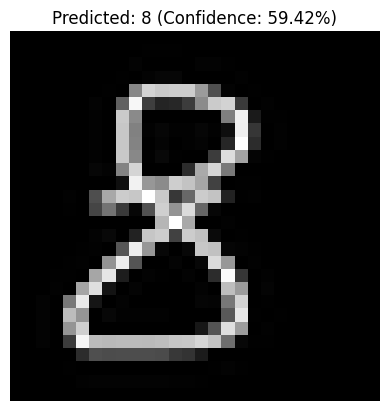

模型预测结果为：8，置信度：59.42%


In [8]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
# ---------- 1. 定义模型结构（必须与训练时完全一致）----------
class MNISTNet(torch.nn.Module):
    def __init__(self, input_dim=784, hidden_dim=500, output_dim=10, dropout_keep_prob=0.9):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=1 - dropout_keep_prob)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 设备（使用训练时的设备）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 实例化模型并加载训练好的参数
model = MNISTNet().to(device)
model.load_state_dict(torch.load('mnist_model.pth', map_location=device, weights_only=True))
model.eval()  # 切换到评估模式，关闭 dropout

# ---------- 2. 预处理图片 ----------
def preprocess_image(image_path):
    # 打开图片，转换为灰度
    img = Image.open(image_path).convert('L')
    
    # 反转颜色：如果是白底黑字，变成黑底白字（MNIST 风格）
    # 检测图片平均亮度，若 > 127 则认为是白底，需要反转
    img_array = np.array(img)
    if img_array.mean() > 127:
        img = Image.fromarray(255 - img_array)  # 反转
    
    # 缩放到 28x28
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    
    # 转换为 Tensor，并归一化到 [0,1]
    transform = transforms.Compose([
        transforms.ToTensor(),           # 变成 (1,28,28) 范围 [0,1]
        transforms.Normalize((0.1307,), (0.3081,))  # 与训练时相同的标准化
    ])
    img_tensor = transform(img).unsqueeze(0)  # 增加 batch 维度 -> (1,1,28,28)
    return img_tensor, img

# ---------- 3. 预测 ----------
image_path = 'my_digit2.png'  # 替换为你的图片路径
img_tensor, original_img = preprocess_image(image_path)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)          # 输出 (1,10)
    probabilities = torch.softmax(output, dim=1)  # 转为概率
    predicted_class = torch.argmax(output, dim=1).item()
    confidence = probabilities[0, predicted_class].item()

# ---------- 4. 显示结果 ----------
plt.imshow(original_img, cmap='gray')
plt.title(f'Predicted: {predicted_class} (Confidence: {confidence:.2%})')
plt.axis('off')
plt.show()
print(f'模型预测结果为：{predicted_class}，置信度：{confidence:.2%}')